<a href="https://colab.research.google.com/github/Saliikaa/Customer-Churn-Prediction/blob/main/AQI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
import warnings
from tensorflow import keras

warnings.filterwarnings("ignore",category=UserWarning)
from statsmodels.tsa.stattools import adfuller, kpss
from sklearn.preprocessing import MinMaxScaler,LabelEncoder,RobustScaler
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout,Conv1D,MaxPooling1D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping




In [3]:
df=pd.read_csv("/content/drive/MyDrive/Colab Notebooks/cscholar/air_pollution_china.csv")
pd.set_option('display.max_columns',None)
df.head()

,PM2.5 (µg/m³),PM10 (µg/m³),NO2 (µg/m³),SO2 (µg/m³),CO (mg/m³),O3 (µg/m³),Temperature (°C),Humidity (%),Wind Speed (m/s),Wind Direction (°),Pressure (hPa),Precipitation (mm),Visibility (km),AQI,Season,City,Latitude,Longitude,Day of Week,Hour,Month,Year,Weather Condition,Station ID
0,94.437337,253.533160,57.759232,3.676372,2.568404,116.383653,4.578449,43.406082,7.861799,266.338889,990.780654,30.034919,18.270028,4,Spring,Shenzhen,36.268122,112.199251,Sunday,2,7,2016,Haze,58
1,194.174790,165.605024,75.117403,22.243199,1.528823,178.428560,37.332250,27.446097,9.742233,27.266465,994.616334,47.454277,2.049126,48,Spring,Shanghai,48.629080,105.238302,Monday,17,11,2017,Cloudy,18
2,45.037661,24.732526,61.400657,2.309529,2.629654,156.354832,30.325762,48.364322,1.749702,258.831639,1009.012850,4.030126,0.813023,49,Autumn,Beijing,32.155184,127.648336,Sunday,6,7,2017,Fog,35
3,76.131857,78.790750,77.274046,24.302389,1.732926,81.611939,7.405654,60.582658,8.791379,306.482163,985.273551,29.051923,14.372230,271,Summer,Shanghai,45.400785,119.615793,Monday,17,3,2020,Snow,77
4,204.127929,62.680686,99.519372,48.842644,2.687827,70.314277,6.125376,79.890364,2.395132,154.210801,1046.865350,14.824943,10.706314,372,Spring,Beijing,40.353740,99.195910,Tuesday,3,12,2020,Clear,47


In [4]:
df["City"].value_counts()

,count
City,
Beijing,629
Chengdu,598
Shanghai,596
Shenzhen,593
Guangzhou,584


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   PM2.5 (µg/m³)       3000 non-null   float64
 1   PM10 (µg/m³)        3000 non-null   float64
 2   NO2 (µg/m³)         3000 non-null   float64
 3   SO2 (µg/m³)         3000 non-null   float64
 4   CO (mg/m³)          3000 non-null   float64
 5   O3 (µg/m³)          3000 non-null   float64
 6   Temperature (°C)    3000 non-null   float64
 7   Humidity (%)        3000 non-null   float64
 8   Wind Speed (m/s)    3000 non-null   float64
 9   Wind Direction (°)  3000 non-null   float64
 10  Pressure (hPa)      3000 non-null   float64
 11  Precipitation (mm)  3000 non-null   float64
 12  Visibility (km)     3000 non-null   float64
 13  AQI                 3000 non-null   int64  
 14  Season              3000 non-null   object 
 15  City                3000 non-null   object 
 16  Latitu

In [6]:
df.isnull().sum()

,0
PM2.5 (µg/m³),0
PM10 (µg/m³),0
NO2 (µg/m³),0
SO2 (µg/m³),0
CO (mg/m³),0
O3 (µg/m³),0
Temperature (°C),0
Humidity (%),0
Wind Speed (m/s),0
Wind Direction (°),0


EDA


In [7]:
df.columns

Index(['PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO2 (µg/m³)', 'SO2 (µg/m³)',
       'CO (mg/m³)', 'O3 (µg/m³)', 'Temperature (°C)', 'Humidity (%)',
       'Wind Speed (m/s)', 'Wind Direction (°)', 'Pressure (hPa)',
       'Precipitation (mm)', 'Visibility (km)', 'AQI', 'Season', 'City',
       'Latitude', 'Longitude', 'Day of Week', 'Hour', 'Month', 'Year',
       'Weather Condition', 'Station ID'],
      dtype='object')

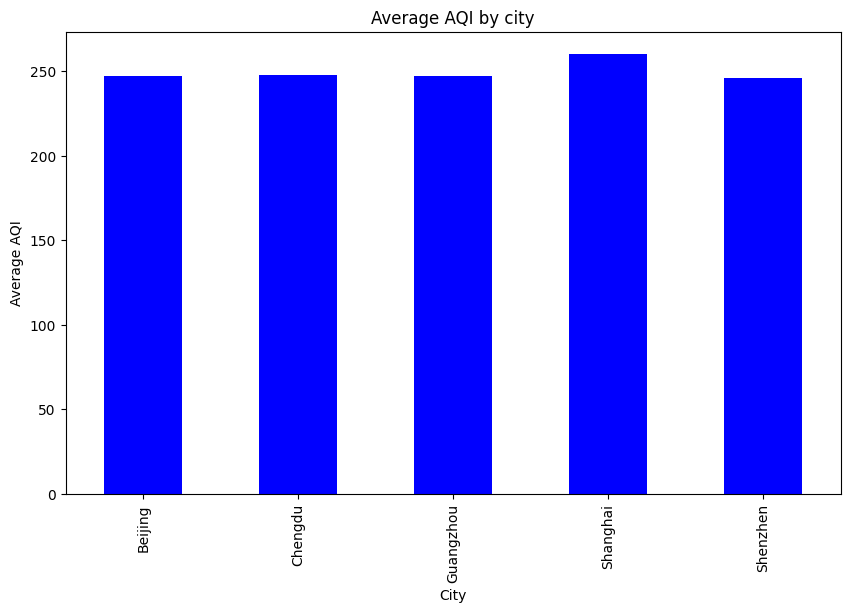

In [8]:
avgaqi=df.groupby('City')['AQI'].mean()
avgaqi.plot(kind='bar',figsize=(10,6),color='blue')
plt.ylabel("Average AQI")
plt.title("Average AQI by city")
plt.show()

 AQI trends over time

In [9]:
df['Date']=pd.to_datetime(df[["Year","Month"]].assign(DAY=1))
monthly_aqi=df.groupby([df['City'],df['Date']])['AQI'].mean().unstack(0)

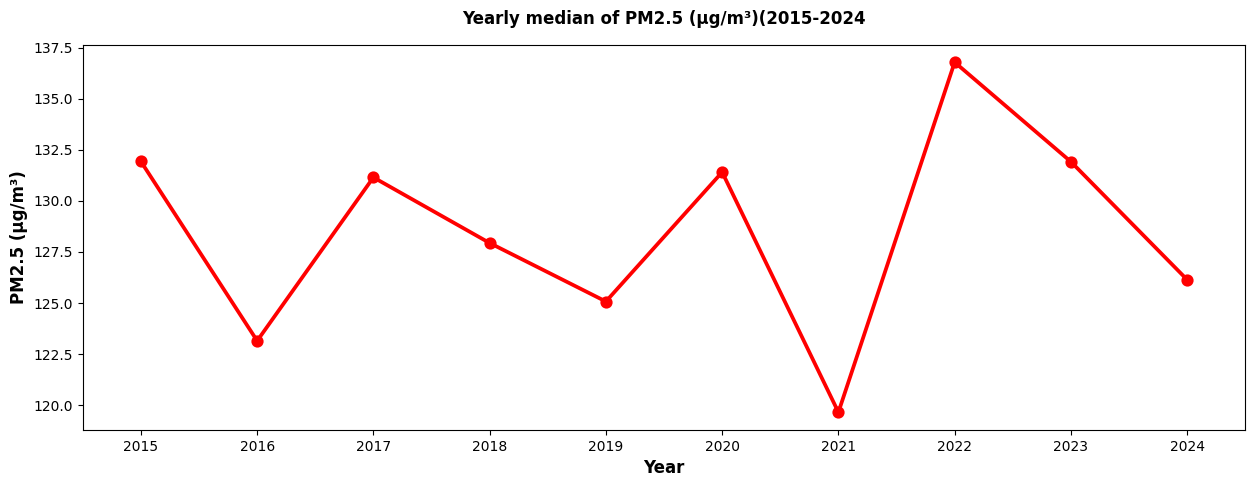

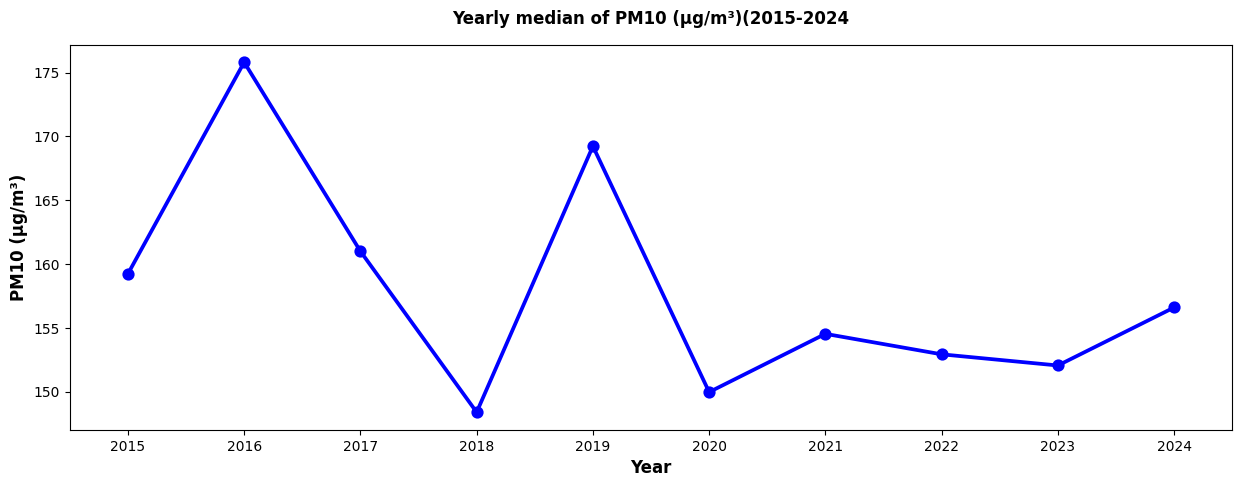

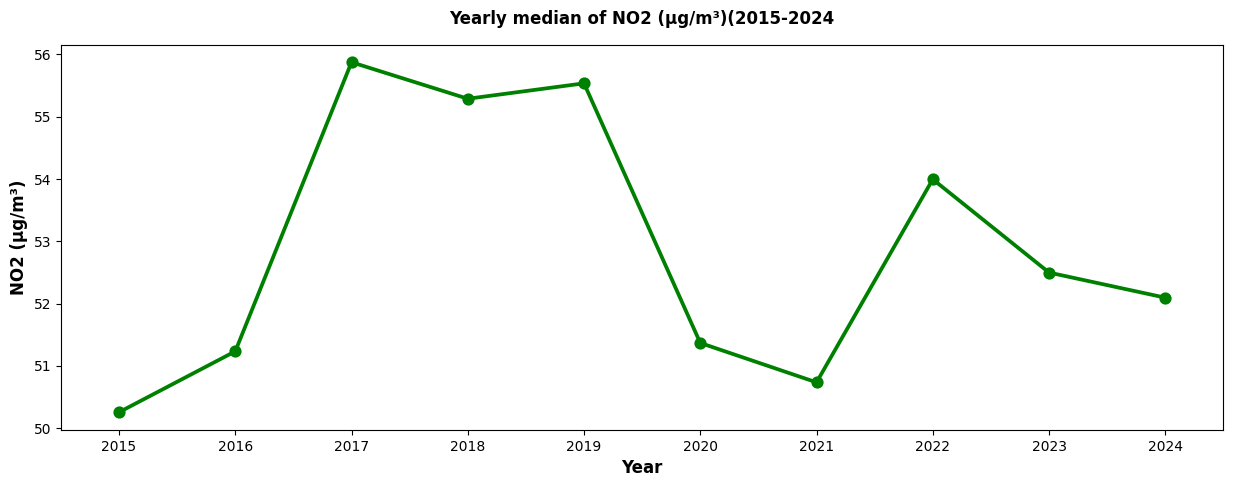

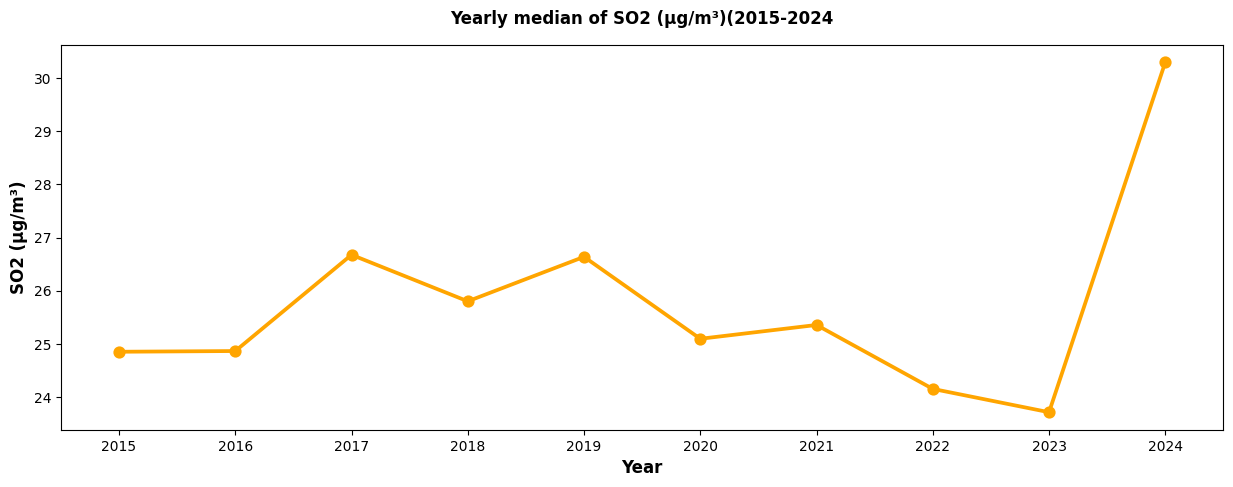

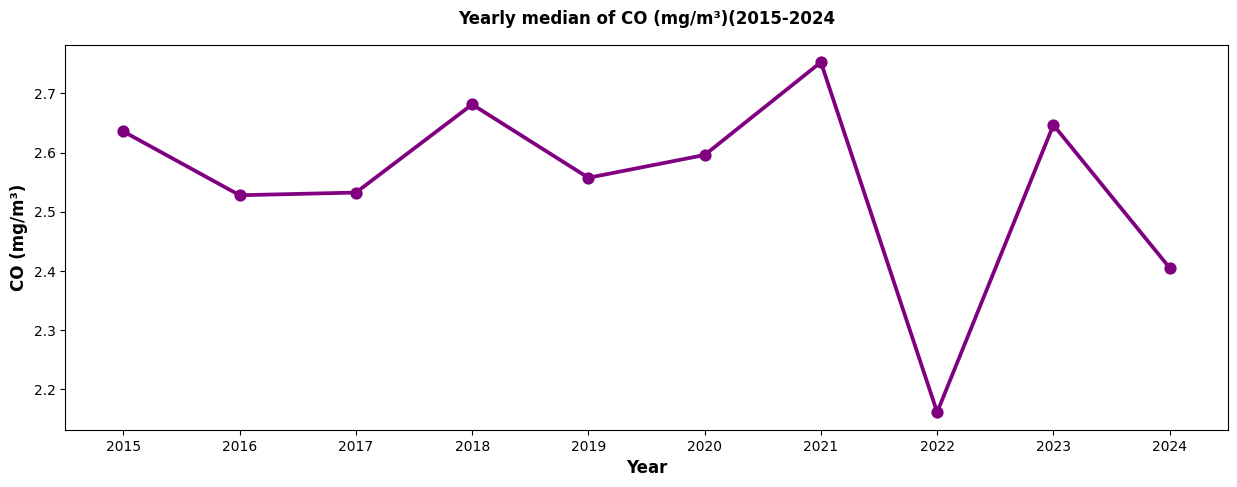

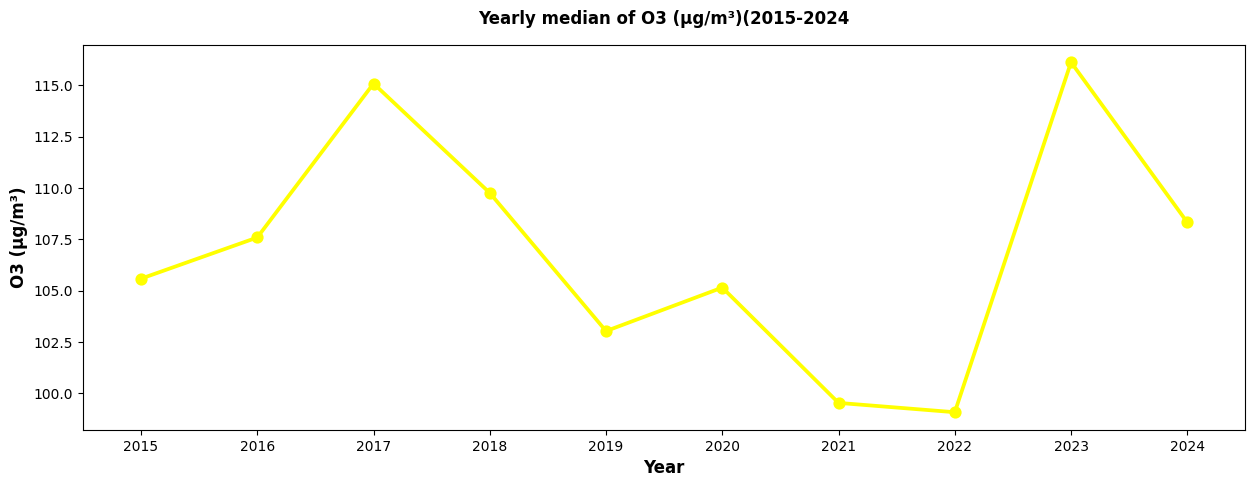

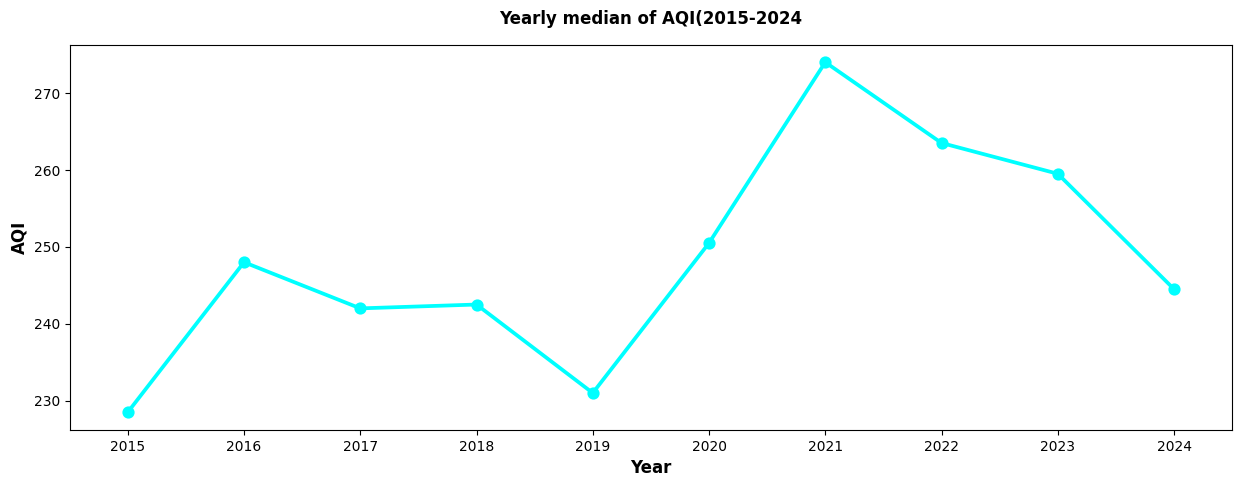

In [10]:
columns_all = ['PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO2 (µg/m³)', 'SO2 (µg/m³)','CO (mg/m³)', 'O3 (µg/m³)','AQI']
colors = ['red', 'blue', 'green', 'orange', 'purple', 'yellow', 'cyan', 'magenta', 'gray', 'brown']
for i, colum in enumerate(columns_all):
    df_aux = df[[colum,'Year']].groupby(["Year"]).median().reset_index().sort_values(by='Year',ascending=False)
    f,ax=plt.subplots(figsize=(15,5))
    sns.pointplot(x='Year', y=str(colum), data=df_aux, markers='o', color=colors[i % len(colors)])
    plt.title(f"Yearly median of {colum}(2015-2024",fontsize=12,pad=15,weight="bold")
    plt.ylabel(colum,fontsize=12,weight="bold")
    plt.xlabel("Year",fontsize=12,weight="bold")
    plt.show()

In [11]:
df.columns

Index(['PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO2 (µg/m³)', 'SO2 (µg/m³)',
       'CO (mg/m³)', 'O3 (µg/m³)', 'Temperature (°C)', 'Humidity (%)',
       'Wind Speed (m/s)', 'Wind Direction (°)', 'Pressure (hPa)',
       'Precipitation (mm)', 'Visibility (km)', 'AQI', 'Season', 'City',
       'Latitude', 'Longitude', 'Day of Week', 'Hour', 'Month', 'Year',
       'Weather Condition', 'Station ID', 'Date'],
      dtype='object')

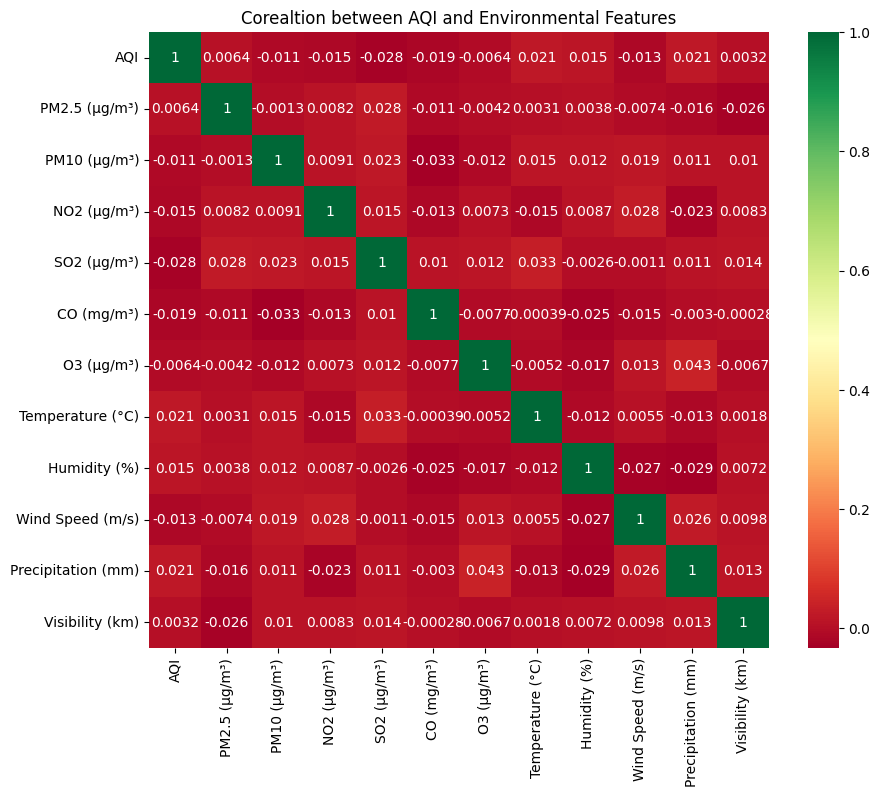

In [12]:
col=[ 'AQI','PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO2 (µg/m³)', 'SO2 (µg/m³)',
       'CO (mg/m³)', 'O3 (µg/m³)', 'Temperature (°C)', 'Humidity (%)',
       'Wind Speed (m/s)', 'Precipitation (mm)','Visibility (km)']
corr=df[col].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr,annot=True,cmap='RdYlGn')
plt.title("Corealtion between AQI and Environmental Features")
plt.show()

Checking for outliers

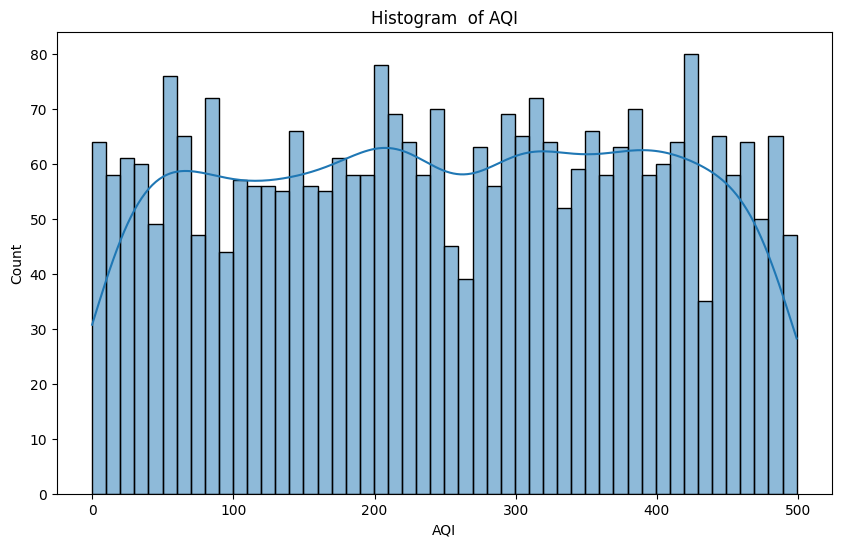

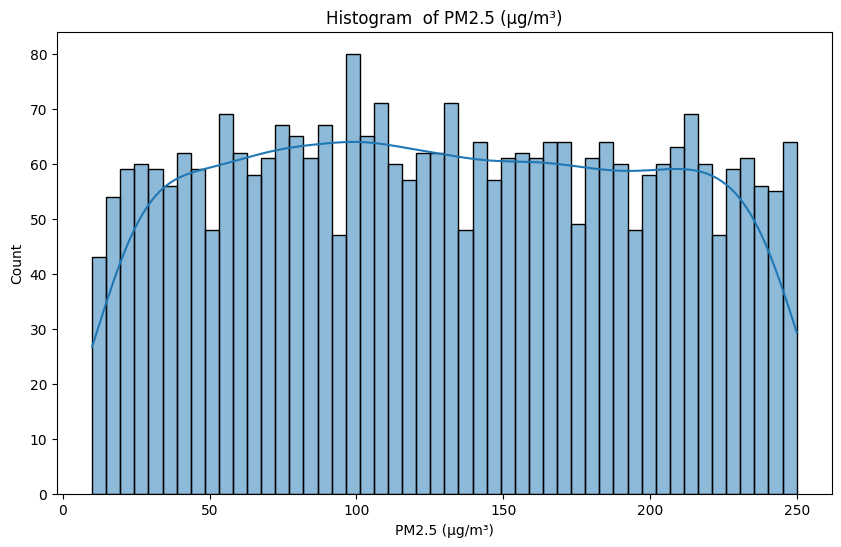

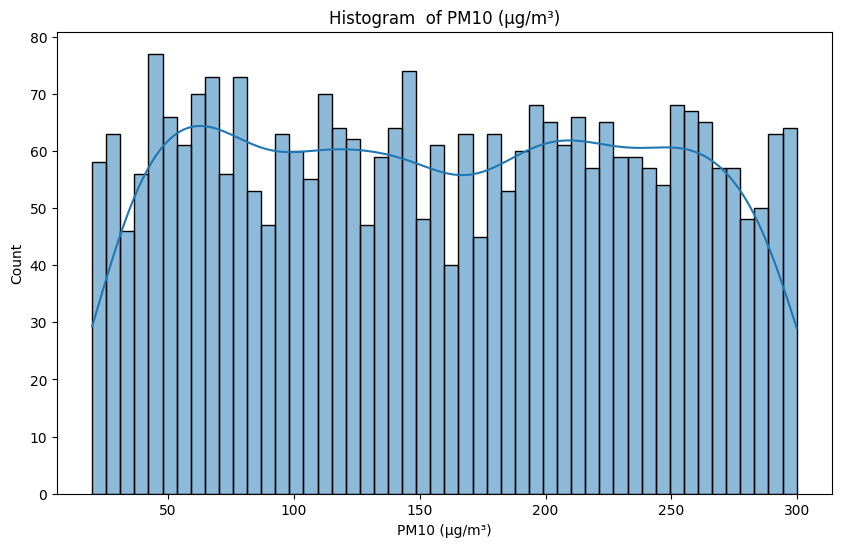

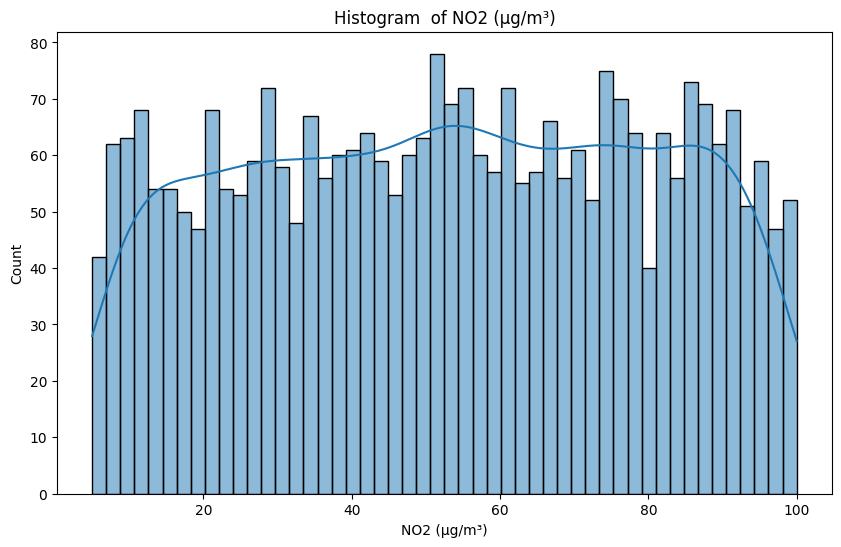

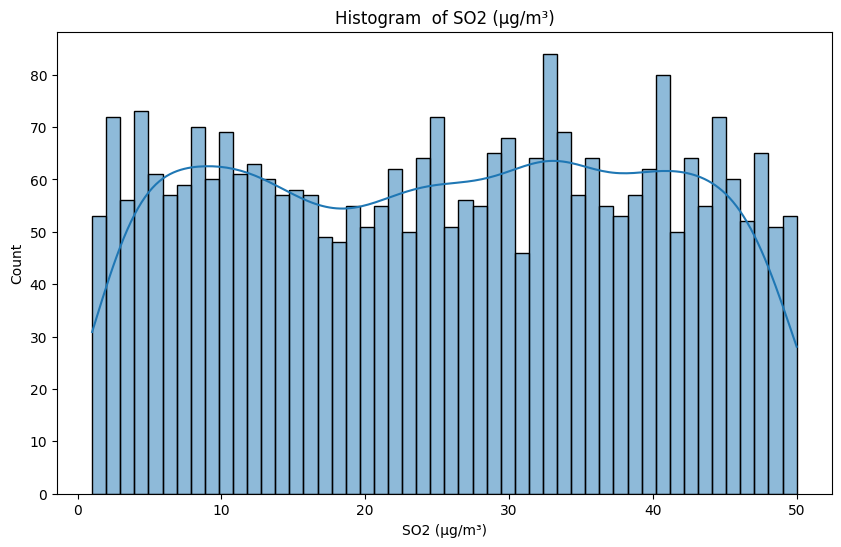

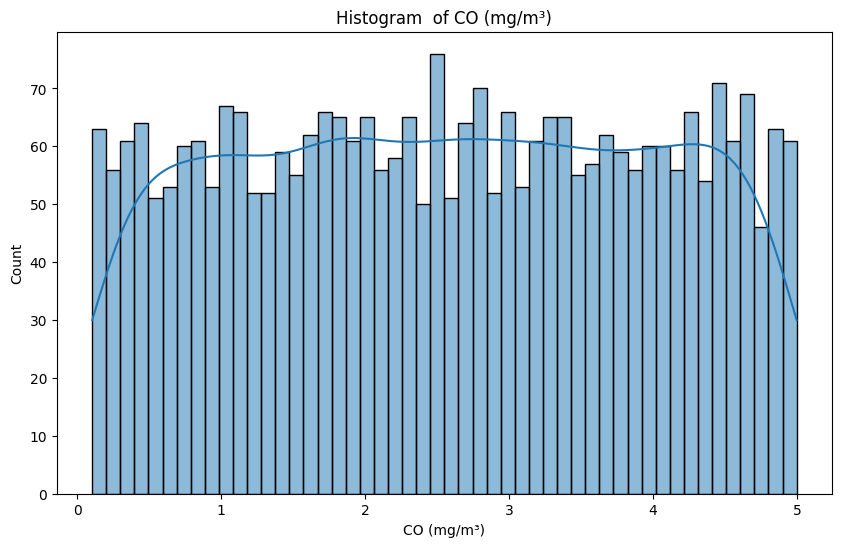

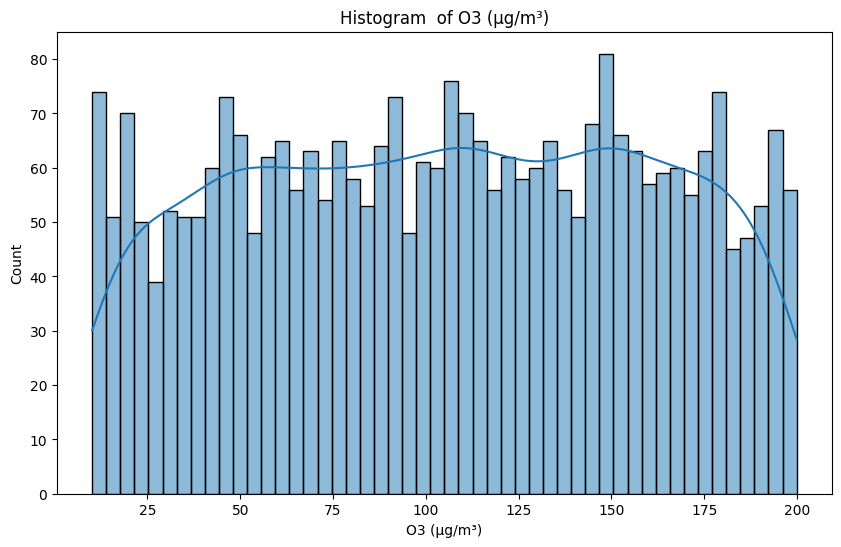

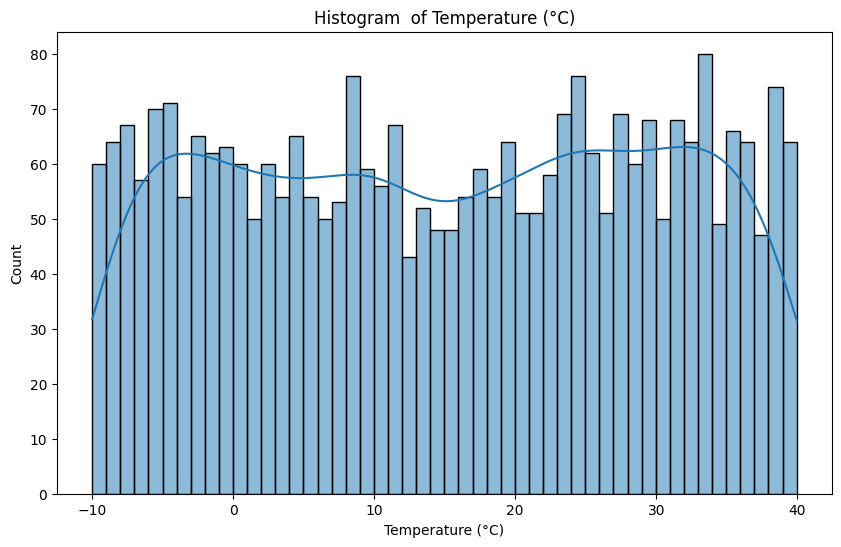

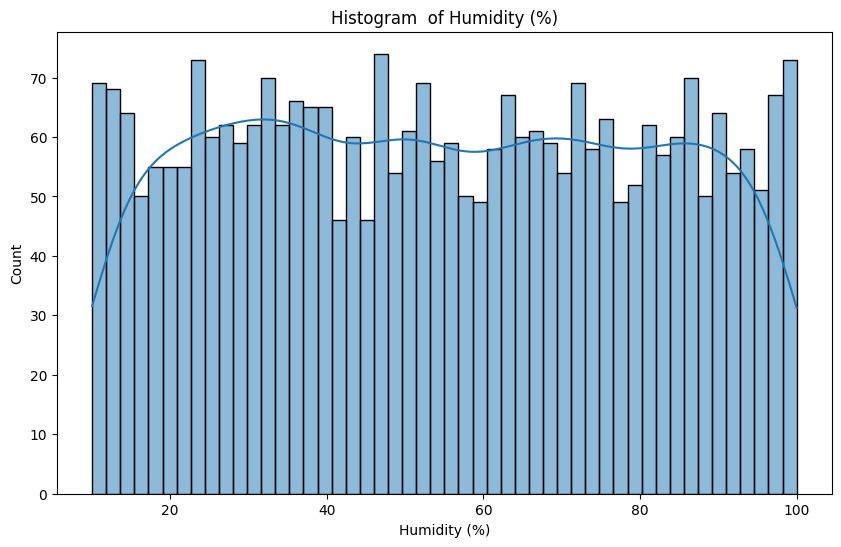

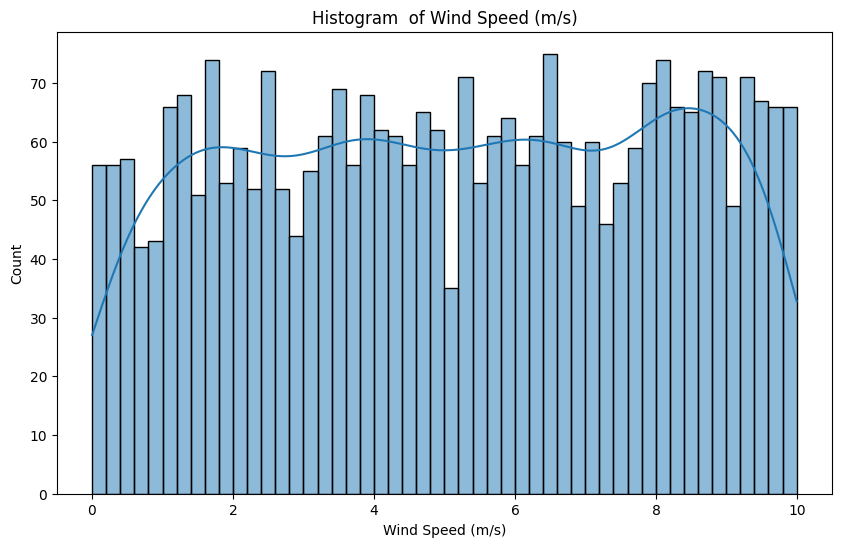

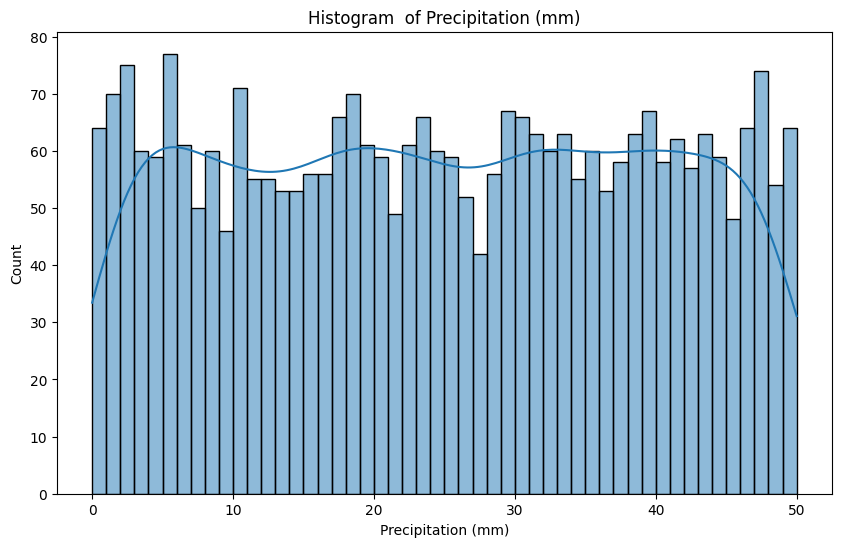

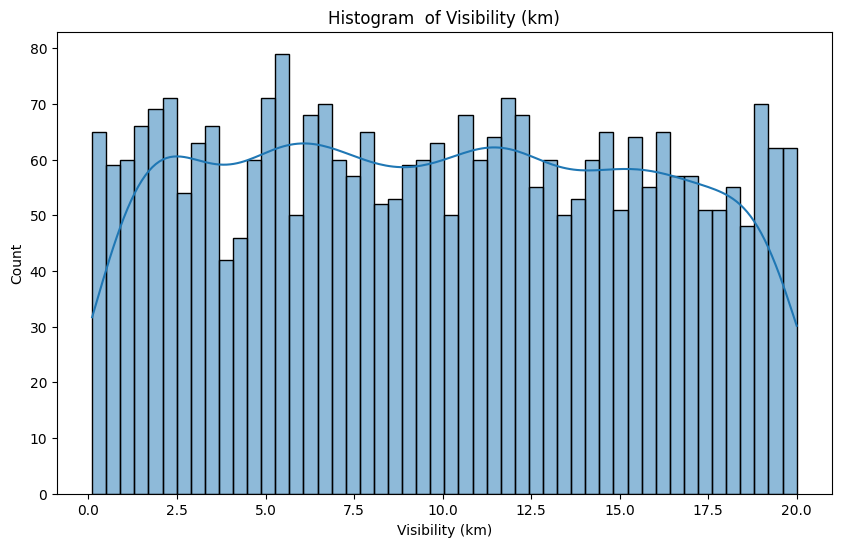

In [13]:
for c in col:
  plt.figure(figsize=(10,6))
  sns.histplot(df[c],kde=True,bins=50)
  plt.title(f"Histogram  of {c}")
  plt.show()

In [14]:
for c in col:
    Q1 = df[c].quantile(0.25)
    Q3 = df[c].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[c] < Q1 - 1.5*IQR) | (df[c] > Q3 + 1.5*IQR)]
    print(f"{c}: {len(outliers)} outliers")


AQI: 0 outliers
PM2.5 (µg/m³): 0 outliers
PM10 (µg/m³): 0 outliers
NO2 (µg/m³): 0 outliers
SO2 (µg/m³): 0 outliers
CO (mg/m³): 0 outliers
O3 (µg/m³): 0 outliers
Temperature (°C): 0 outliers
Humidity (%): 0 outliers
Wind Speed (m/s): 0 outliers
Precipitation (mm): 0 outliers
Visibility (km): 0 outliers


Checking the pollution during the season

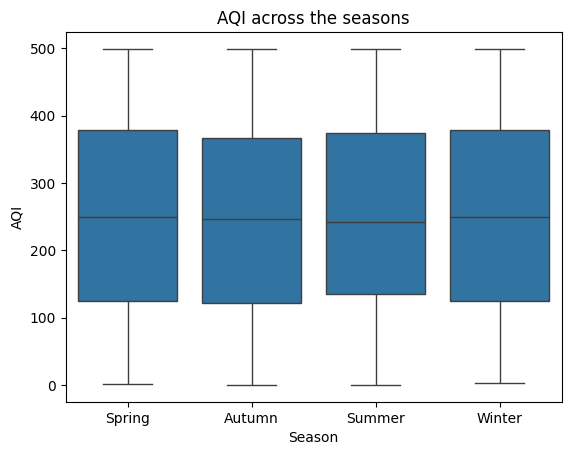

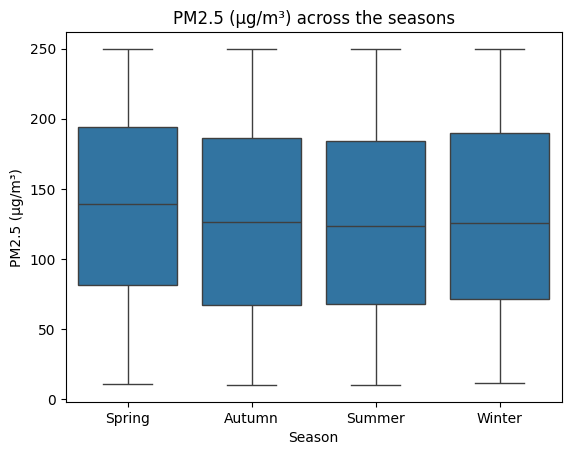

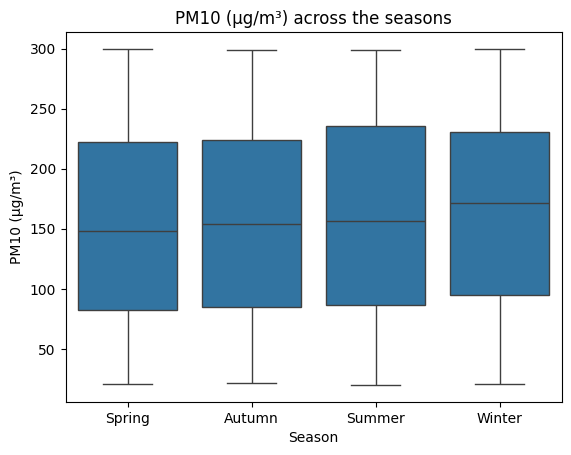

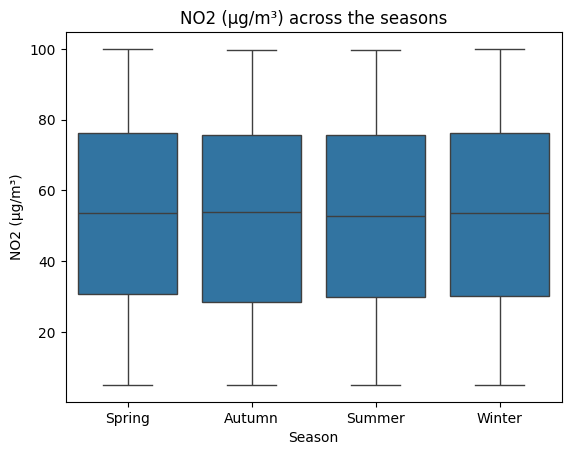

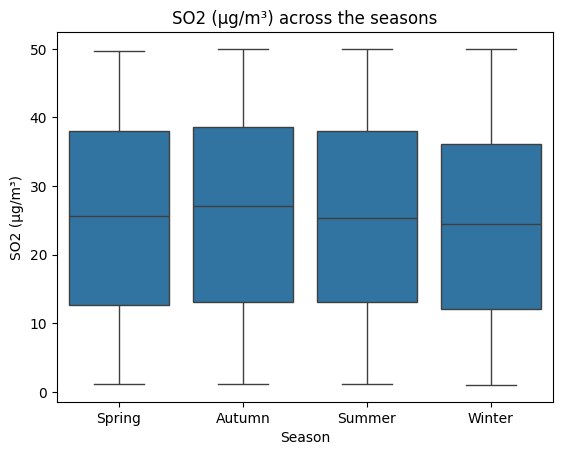

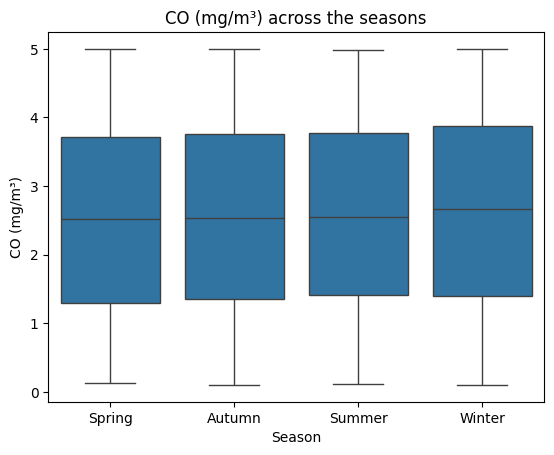

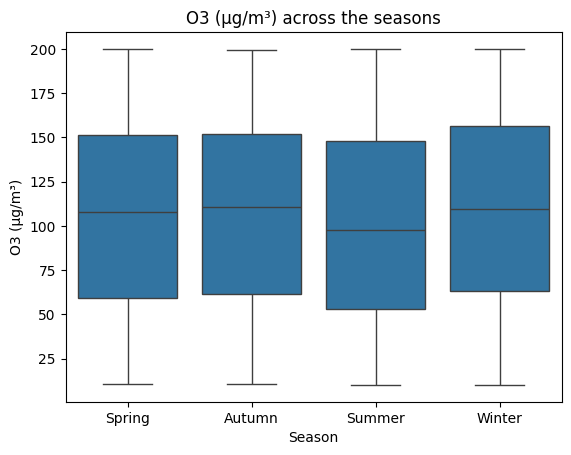

In [15]:
pollutants=[ 'AQI','PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO2 (µg/m³)', 'SO2 (µg/m³)',
       'CO (mg/m³)', 'O3 (µg/m³)']
for p in pollutants:
  sns.boxplot(x='Season',y=p,data=df)
  plt.title(f"{p} across the seasons")
  plt.show()

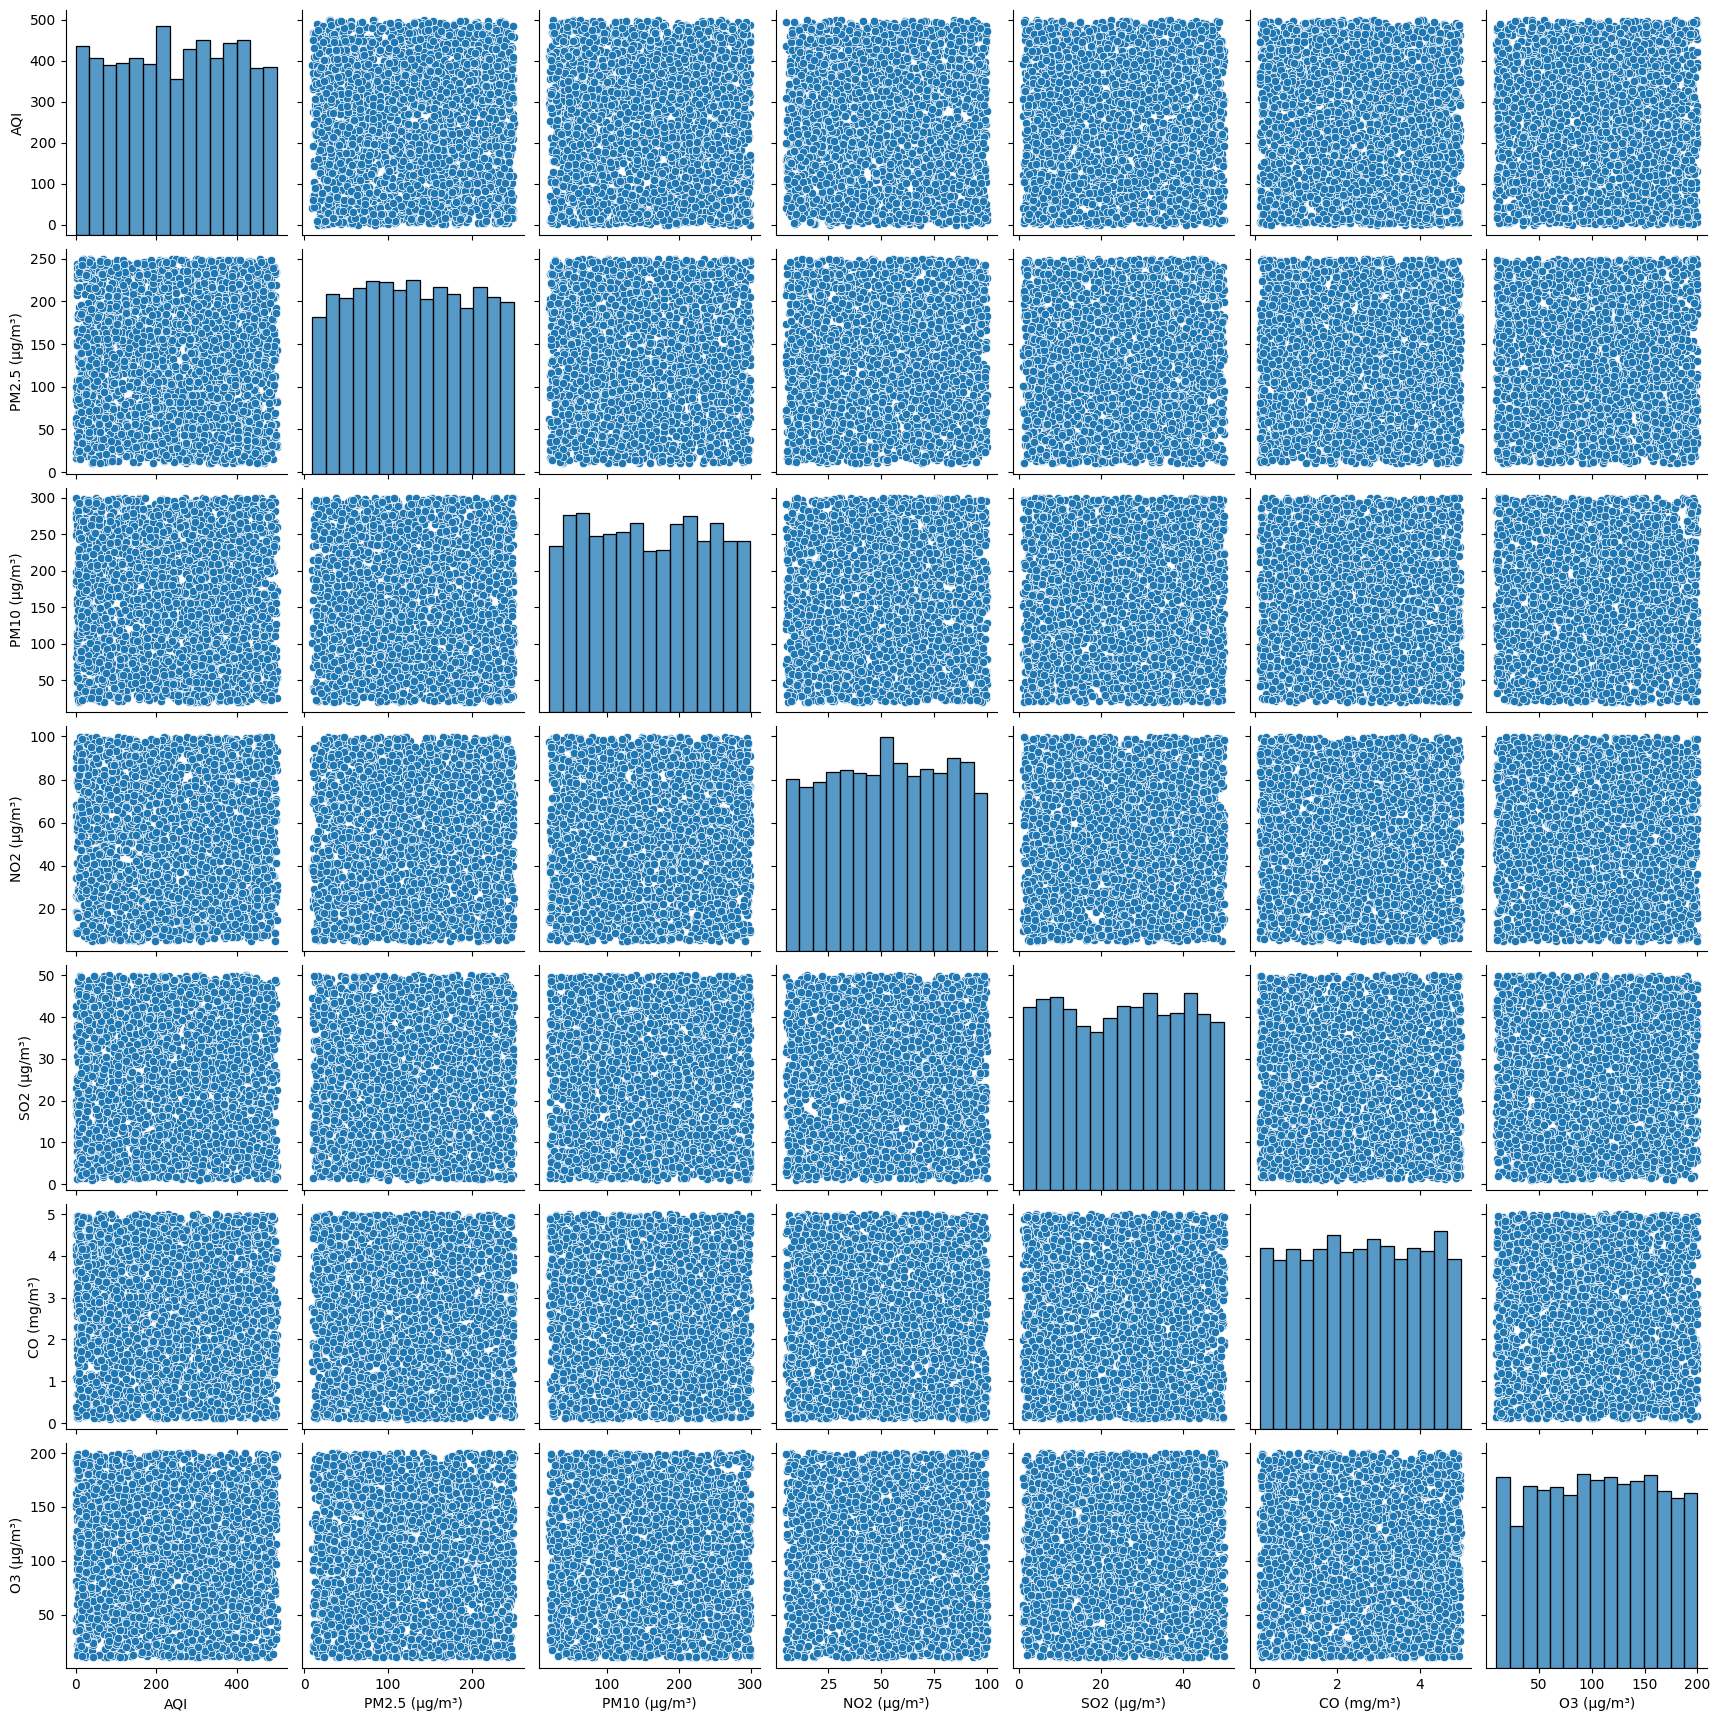

In [16]:
sns.pairplot(df, vars=['AQI','PM2.5 (µg/m³)','PM10 (µg/m³)','NO2 (µg/m³)','SO2 (µg/m³)','CO (mg/m³)','O3 (µg/m³)'])
plt.show()


In [17]:
duplicate=df[df.duplicated()]
duplicate
df.head()

,PM2.5 (µg/m³),PM10 (µg/m³),NO2 (µg/m³),SO2 (µg/m³),CO (mg/m³),O3 (µg/m³),Temperature (°C),Humidity (%),Wind Speed (m/s),Wind Direction (°),Pressure (hPa),Precipitation (mm),Visibility (km),AQI,Season,City,Latitude,Longitude,Day of Week,Hour,Month,Year,Weather Condition,Station ID,Date
0,94.437337,253.533160,57.759232,3.676372,2.568404,116.383653,4.578449,43.406082,7.861799,266.338889,990.780654,30.034919,18.270028,4,Spring,Shenzhen,36.268122,112.199251,Sunday,2,7,2016,Haze,58,2016-07-01
1,194.174790,165.605024,75.117403,22.243199,1.528823,178.428560,37.332250,27.446097,9.742233,27.266465,994.616334,47.454277,2.049126,48,Spring,Shanghai,48.629080,105.238302,Monday,17,11,2017,Cloudy,18,2017-11-01
2,45.037661,24.732526,61.400657,2.309529,2.629654,156.354832,30.325762,48.364322,1.749702,258.831639,1009.012850,4.030126,0.813023,49,Autumn,Beijing,32.155184,127.648336,Sunday,6,7,2017,Fog,35,2017-07-01
3,76.131857,78.790750,77.274046,24.302389,1.732926,81.611939,7.405654,60.582658,8.791379,306.482163,985.273551,29.051923,14.372230,271,Summer,Shanghai,45.400785,119.615793,Monday,17,3,2020,Snow,77,2020-03-01
4,204.127929,62.680686,99.519372,48.842644,2.687827,70.314277,6.125376,79.890364,2.395132,154.210801,1046.865350,14.824943,10.706314,372,Spring,Beijing,40.353740,99.195910,Tuesday,3,12,2020,Clear,47,2020-12-01


In [18]:
# ===== Folium map (avg AQI per city-Year) =====
avg_city_Year = df.groupby(['City','Year'])['AQI'].mean().reset_index()
coords = df.groupby('City')[['Latitude','Longitude']].mean().reset_index()
avg_city_Year = avg_city_Year.merge(coords, on='City', how='left').dropna(subset=['Latitude','Longitude'])
np.random.seed(2)
avg_city_Year['Latitude'] += np.random.uniform(-0.03, 0.03, len(avg_city_Year))
avg_city_Year['Longitude'] += np.random.uniform(-0.03, 0.03, len(avg_city_Year))

m = folium.Map(location=[df['Latitude'].mean(), df['Longitude'].mean()], zoom_start=4)
for _, r in avg_city_Year.iterrows():
    folium.CircleMarker(
        location=[r['Latitude'], r['Longitude']],
        radius=4 + (r['AQI'] - avg_city_Year['AQI'].min())/(avg_city_Year['AQI'].max() - avg_city_Year['AQI'].min() + 1) * 6,
        popup=f"{r['City']} {int(r['Year'])} — AQI: {r['AQI']:.1f}",
        color=None, fill=True, fill_color='crimson', fill_opacity=0.7
    ).add_to(m)
m


In [19]:
df.head()

,PM2.5 (µg/m³),PM10 (µg/m³),NO2 (µg/m³),SO2 (µg/m³),CO (mg/m³),O3 (µg/m³),Temperature (°C),Humidity (%),Wind Speed (m/s),Wind Direction (°),Pressure (hPa),Precipitation (mm),Visibility (km),AQI,Season,City,Latitude,Longitude,Day of Week,Hour,Month,Year,Weather Condition,Station ID,Date
0,94.437337,253.533160,57.759232,3.676372,2.568404,116.383653,4.578449,43.406082,7.861799,266.338889,990.780654,30.034919,18.270028,4,Spring,Shenzhen,36.268122,112.199251,Sunday,2,7,2016,Haze,58,2016-07-01
1,194.174790,165.605024,75.117403,22.243199,1.528823,178.428560,37.332250,27.446097,9.742233,27.266465,994.616334,47.454277,2.049126,48,Spring,Shanghai,48.629080,105.238302,Monday,17,11,2017,Cloudy,18,2017-11-01
2,45.037661,24.732526,61.400657,2.309529,2.629654,156.354832,30.325762,48.364322,1.749702,258.831639,1009.012850,4.030126,0.813023,49,Autumn,Beijing,32.155184,127.648336,Sunday,6,7,2017,Fog,35,2017-07-01
3,76.131857,78.790750,77.274046,24.302389,1.732926,81.611939,7.405654,60.582658,8.791379,306.482163,985.273551,29.051923,14.372230,271,Summer,Shanghai,45.400785,119.615793,Monday,17,3,2020,Snow,77,2020-03-01
4,204.127929,62.680686,99.519372,48.842644,2.687827,70.314277,6.125376,79.890364,2.395132,154.210801,1046.865350,14.824943,10.706314,372,Spring,Beijing,40.353740,99.195910,Tuesday,3,12,2020,Clear,47,2020-12-01


***Time Series Analysis**


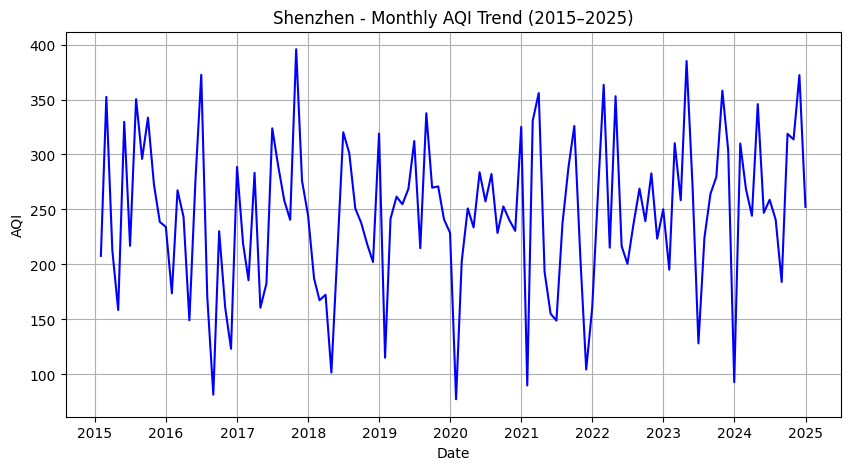

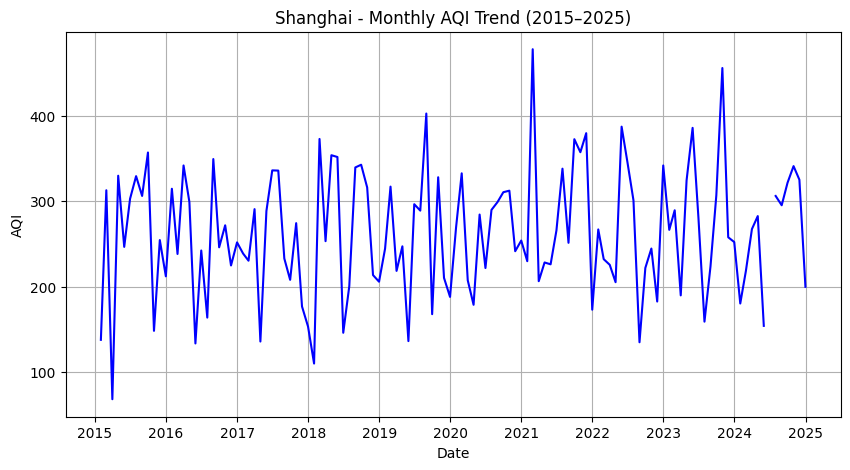

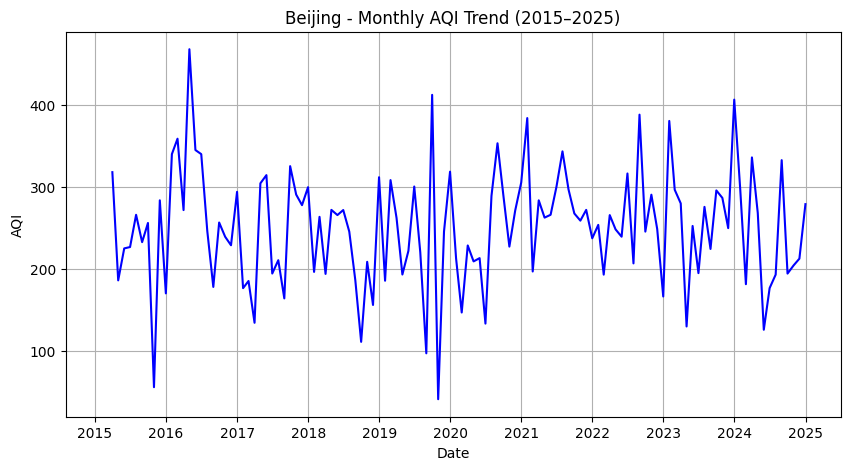

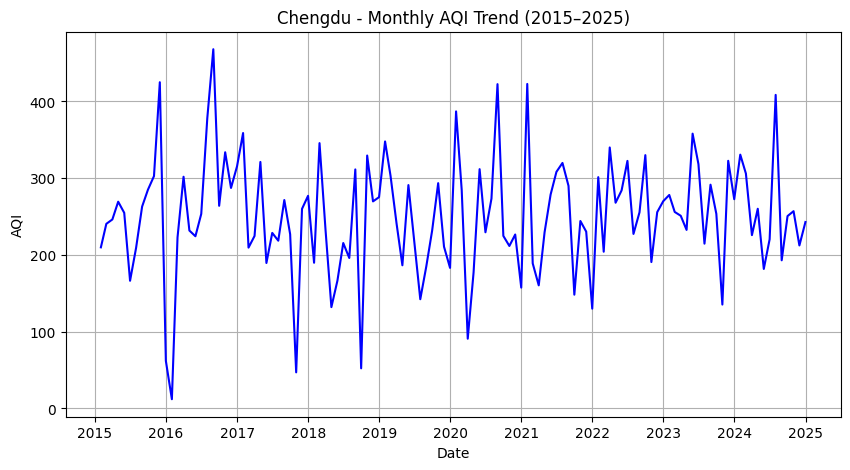

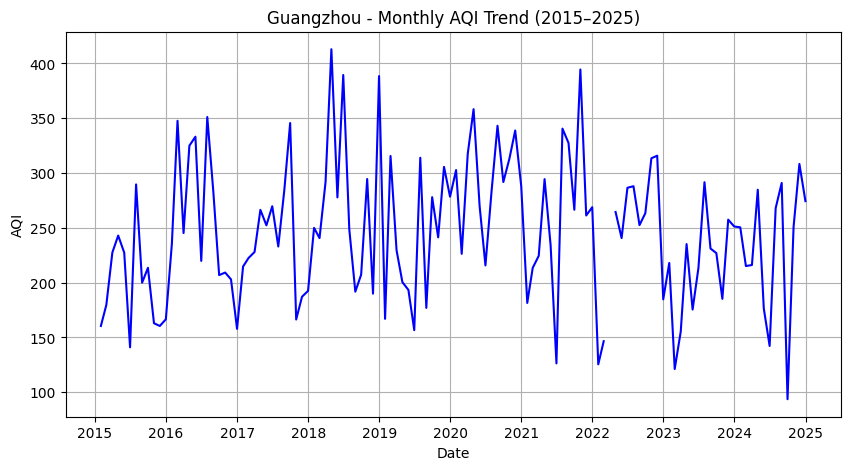

In [20]:
cities=df["City"].unique()
for city in cities:

    city_df=df[df['City']==city].groupby("Date")["AQI"].mean().reset_index()
    city_df=city_df.set_index('Date').resample('ME').mean()
    plt.figure(figsize=(10, 5))
    plt.plot(city_df.index, city_df.values, color='blue')
    plt.title(f"{city} - Monthly AQI Trend (2015–2025)")
    plt.xlabel("Date")
    plt.ylabel("AQI")
    plt.grid(True)
    plt.show()


In [21]:
df=df.drop(columns=['Station ID','Latitude','Longitude','Year'])

In [22]:
df.head()

,PM2.5 (µg/m³),PM10 (µg/m³),NO2 (µg/m³),SO2 (µg/m³),CO (mg/m³),O3 (µg/m³),Temperature (°C),Humidity (%),Wind Speed (m/s),Wind Direction (°),Pressure (hPa),Precipitation (mm),Visibility (km),AQI,Season,City,Day of Week,Hour,Month,Weather Condition,Date
0,94.437337,253.533160,57.759232,3.676372,2.568404,116.383653,4.578449,43.406082,7.861799,266.338889,990.780654,30.034919,18.270028,4,Spring,Shenzhen,Sunday,2,7,Haze,2016-07-01
1,194.174790,165.605024,75.117403,22.243199,1.528823,178.428560,37.332250,27.446097,9.742233,27.266465,994.616334,47.454277,2.049126,48,Spring,Shanghai,Monday,17,11,Cloudy,2017-11-01
2,45.037661,24.732526,61.400657,2.309529,2.629654,156.354832,30.325762,48.364322,1.749702,258.831639,1009.012850,4.030126,0.813023,49,Autumn,Beijing,Sunday,6,7,Fog,2017-07-01
3,76.131857,78.790750,77.274046,24.302389,1.732926,81.611939,7.405654,60.582658,8.791379,306.482163,985.273551,29.051923,14.372230,271,Summer,Shanghai,Monday,17,3,Snow,2020-03-01
4,204.127929,62.680686,99.519372,48.842644,2.687827,70.314277,6.125376,79.890364,2.395132,154.210801,1046.865350,14.824943,10.706314,372,Spring,Beijing,Tuesday,3,12,Clear,2020-12-01


Encoding and scaling the data

In [23]:
columns_to_encode = ['City', 'Season', 'Weather Condition']
df_encoded = pd.get_dummies(df, columns=columns_to_encode, dtype=int)
df_encoded.head()


,PM2.5 (µg/m³),PM10 (µg/m³),NO2 (µg/m³),SO2 (µg/m³),CO (mg/m³),O3 (µg/m³),Temperature (°C),Humidity (%),Wind Speed (m/s),Wind Direction (°),Pressure (hPa),Precipitation (mm),Visibility (km),AQI,Day of Week,Hour,Month,Date,City_Beijing,City_Chengdu,City_Guangzhou,City_Shanghai,City_Shenzhen,Season_Autumn,Season_Spring,Season_Summer,Season_Winter,Weather Condition_Clear,Weather Condition_Cloudy,Weather Condition_Fog,Weather Condition_Haze,Weather Condition_Rain,Weather Condition_Snow
0,94.437337,253.533160,57.759232,3.676372,2.568404,116.383653,4.578449,43.406082,7.861799,266.338889,990.780654,30.034919,18.270028,4,Sunday,2,7,2016-07-01,0,0,0,0,1,0,1,0,0,0,0,0,1,0,0
1,194.174790,165.605024,75.117403,22.243199,1.528823,178.428560,37.332250,27.446097,9.742233,27.266465,994.616334,47.454277,2.049126,48,Monday,17,11,2017-11-01,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0
2,45.037661,24.732526,61.400657,2.309529,2.629654,156.354832,30.325762,48.364322,1.749702,258.831639,1009.012850,4.030126,0.813023,49,Sunday,6,7,2017-07-01,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0
3,76.131857,78.790750,77.274046,24.302389,1.732926,81.611939,7.405654,60.582658,8.791379,306.482163,985.273551,29.051923,14.372230,271,Monday,17,3,2020-03-01,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1
4,204.127929,62.680686,99.519372,48.842644,2.687827,70.314277,6.125376,79.890364,2.395132,154.210801,1046.865350,14.824943,10.706314,372,Tuesday,3,12,2020-12-01,1,0,0,0,0,0,1,0,0,1,0,0,0,0,0


In [24]:
num_cols = ['Day of Week', 'Hour', 'Month', 'Wind Direction (°)']
df_encoded[num_cols] = df_encoded[num_cols].apply(pd.to_numeric, errors='coerce')

# Hour ranges from 0 to 23 (so the period is 24)
hour_period = 24.0

df_encoded['Hour_sin'] = np.sin(df_encoded['Hour'] * (2. * np.pi / hour_period))
df_encoded['Hour_cos'] = np.cos(df_encoded['Hour'] * (2. * np.pi / hour_period))

# We can now drop the original 'Hour' column
df_encoded = df_encoded.drop('Hour', axis=1)
# For Month (assuming your data is 1 through 12)
month_period = 12.0
df_encoded['Month_sin'] = np.sin(df_encoded['Month'] * (2. * np.pi / month_period))
df_encoded['Month_cos'] = np.cos(df_encoded['Month'] * (2. * np.pi / month_period))
df_encoded = df_encoded.drop('Month', axis=1)

# For Day of Week (assuming your data is 0 through 6)
# NOTE: Pandas get_dummies might have turned Day of Week names into columns.
# If 'Day of Week' is still a single column of numbers (0-6 or 1-7), run this:
df_encoded['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df_encoded['Day_num'] = df_encoded['Date'].dt.weekday   # 0=Mon ... 6=Sun

day_period = 7.0
df_encoded['Day_sin'] = np.sin(df_encoded['Day_num'] * (2 * np.pi / day_period))
df_encoded['Day_cos'] = np.cos(df_encoded['Day_num'] * (2 * np.pi / day_period))

df_encoded = df_encoded.drop(columns=['Day of Week', 'Day_num', 'Date'], errors='ignore')



# For Wind Direction (0 to 360 degrees)
direction_period = 360.0
df_encoded['Wind_Dir_sin'] = np.sin(df_encoded['Wind Direction (°)'] * (2. * np.pi / direction_period))
df_encoded['Wind_Dir_cos'] = np.cos(df_encoded['Wind Direction (°)'] * (2. * np.pi / direction_period))
df_encoded = df_encoded.drop('Wind Direction (°)', axis=1)


In [25]:
df_encoded.isnull().sum()

,0
PM2.5 (µg/m³),0
PM10 (µg/m³),0
NO2 (µg/m³),0
SO2 (µg/m³),0
CO (mg/m³),0
O3 (µg/m³),0
Temperature (°C),0
Humidity (%),0
Wind Speed (m/s),0
Pressure (hPa),0


In [26]:
print("dtypes:")
print(df_encoded[['Day_sin','Day_cos']].dtypes)
print("\nNaN counts:")
print(df_encoded[['Day_sin','Day_cos']].isna().sum())
print("\nSample values:")
print(df_encoded[['Day_sin','Day_cos']].head(5))

dtypes:
Day_sin    float64
Day_cos    float64
dtype: object

NaN counts:
Day_sin    0
Day_cos    0
dtype: int64

Sample values:
    Day_sin   Day_cos
0 -0.433884 -0.900969
1  0.974928 -0.222521
2 -0.974928 -0.222521
3 -0.781831  0.623490
4  0.781831  0.623490


In [27]:
# Fill NaN values with the mean of the column
df_encoded['Day_sin'] = df_encoded['Day_sin'].fillna(df_encoded['Day_sin'].mean())
df_encoded['Day_cos'] = df_encoded['Day_cos'].fillna(df_encoded['Day_cos'].mean())


In [28]:
df_encoded.isnull().sum()

,0
PM2.5 (µg/m³),0
PM10 (µg/m³),0
NO2 (µg/m³),0
SO2 (µg/m³),0
CO (mg/m³),0
O3 (µg/m³),0
Temperature (°C),0
Humidity (%),0
Wind Speed (m/s),0
Pressure (hPa),0


In [29]:
df_encoded.head()

,PM2.5 (µg/m³),PM10 (µg/m³),NO2 (µg/m³),SO2 (µg/m³),CO (mg/m³),O3 (µg/m³),Temperature (°C),Humidity (%),Wind Speed (m/s),Pressure (hPa),Precipitation (mm),Visibility (km),AQI,City_Beijing,City_Chengdu,City_Guangzhou,City_Shanghai,City_Shenzhen,Season_Autumn,Season_Spring,Season_Summer,Season_Winter,Weather Condition_Clear,Weather Condition_Cloudy,Weather Condition_Fog,Weather Condition_Haze,Weather Condition_Rain,Weather Condition_Snow,Hour_sin,Hour_cos,Month_sin,Month_cos,Day_sin,Day_cos,Wind_Dir_sin,Wind_Dir_cos
0,94.437337,253.533160,57.759232,3.676372,2.568404,116.383653,4.578449,43.406082,7.861799,990.780654,30.034919,18.270028,4,0,0,0,0,1,0,1,0,0,0,0,0,1,0,0,0.500000,8.660254e-01,-5.000000e-01,-8.660254e-01,-0.433884,-0.900969,-0.997959,-0.063855
1,194.174790,165.605024,75.117403,22.243199,1.528823,178.428560,37.332250,27.446097,9.742233,994.616334,47.454277,2.049126,48,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,-0.965926,-2.588190e-01,-5.000000e-01,8.660254e-01,0.974928,-0.222521,0.458129,0.888886
2,45.037661,24.732526,61.400657,2.309529,2.629654,156.354832,30.325762,48.364322,1.749702,1009.012850,4.030126,0.813023,49,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1.000000,6.123234e-17,-5.000000e-01,-8.660254e-01,-0.974928,-0.222521,-0.981062,-0.193693
3,76.131857,78.790750,77.274046,24.302389,1.732926,81.611939,7.405654,60.582658,8.791379,985.273551,29.051923,14.372230,271,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,-0.965926,-2.588190e-01,1.000000e+00,6.123234e-17,-0.781831,0.623490,-0.804042,0.594573
4,204.127929,62.680686,99.519372,48.842644,2.687827,70.314277,6.125376,79.890364,2.395132,1046.865350,14.824943,10.706314,372,1,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0.707107,7.071068e-01,-2.449294e-16,1.000000e+00,0.781831,0.623490,0.435061,-0.900401


Spilt the data

In [30]:
train_size=int(len(df_encoded)*0.8)

In [31]:
train_data=df_encoded.iloc[0:train_size].copy()
test_data=df_encoded.iloc[train_size:].copy()
#train
x_train=train_data.drop(columns=["AQI"])
y_train=train_data['AQI']
#test
x_test=test_data.drop(columns=['AQI'])
y_test=test_data["AQI"]

In [32]:
print(f"train data: {len(train_data)}")
print(f"test data: {len(test_data)}")
print(f"x_train {x_train.shape}")
print(f"y_train {y_train.shape}")
print(f"x_test {x_test.shape}")
print(f"y_test {y_test.shape}")

train data: 2400
test data: 600
x_train (2400, 35)
y_train (2400,)
x_test (600, 35)
y_test (600,)


Scaling

In [33]:
scale=RobustScaler()
x_train_scale=scale.fit_transform(x_train)
x_test_scale=scale.transform(x_test)
target_scaler = RobustScaler()
y_train_scaled = target_scaler.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = target_scaler.transform(y_test.values.reshape(-1, 1))

In [34]:
def create_sequences(X_data, y_data, time_steps=1):
    Xs, ys = [], []
    for i in range(len(X_data) - time_steps):
        # Get the sequence of X values for the current time window
        v = X_data[i:(i + time_steps)]
        Xs.append(v)
        # Get the target y value immediately after the time window ends
        ys.append(y_data[i + time_steps])
    return np.array(Xs), np.array(ys)

# Define how many past hours/days the LSTM should look at to predict the future
# For example, look at the past 24 time steps (hours, in your case)
TIME_STEPS =180

X_train_3d, y_train_3d = create_sequences(x_train_scale, y_train_scaled, TIME_STEPS)
X_test_3d, y_test_3d = create_sequences(x_test_scale, y_test_scaled, TIME_STEPS)

print(f"Training data shape: {X_train_3d.shape}")
print(f"Training data shape: {X_test_3d.shape}")

# Expected output: (number_of_training_samples, 24, number_of_features)


Training data shape: (2220, 180, 35)
Training data shape: (420, 180, 35)


In [ ]:


# Define the model architecture
model = Sequential()

# Add the first LSTM layer
# Input shape matches your data: (time_steps=24, features=35)
model.add(LSTM(units=128, return_sequences=True, input_shape=(TIME_STEPS,X_train_3d.shape[2])))
model.add(Dropout(0.2)) # Optional: adds regularization



#add thirt layer
model.add(Dense(units=64, activation='relu'))
model.add(Dropout(0.2))
# Add the output layer (Dense layer with 1 unit for predicting a single AQI value)
model.add(Dense(units=1))

# Compile the model
# Use 'mean_squared_error' (mse) for regression tasks like AQI prediction
model.compile(optimizer='adam', loss='mse')

# View the model structure
model.summary()
early_stopping_monitor = EarlyStopping(
    monitor='val_loss',     # The metric to monitor (validation loss is standard)
    min_delta=0.001,        # Minimum change in the monitored quantity to qualify as an improvement
    patience=10,            # Number of epochs with no improvement after which training will be stopped
    verbose=1,              # Log when the training stops
    mode='min',             # Stop when the quantity monitored has stopped decreasing
    restore_best_weights=True # Restores model weights from the epoch with the best value of the monitored quantity
)
# Train the model
history = model.fit(
    X_train_3d, y_train_3d,
    epochs=100,           # Number of times to loop through the data (adjust as needed)
    batch_size=32,       # Number of samples processed before the model is updated
    validation_split=0.2, # Use 20% of training data for validation during training
    callbacks=[early_stopping_monitor],# <-- This line enables early stopping
    shuffle=False        # CRITICAL: Do not shuffle time series data during training
)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 180, 128)       │        83,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 180, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 180, 64)        │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 180, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 180, 1)         │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 92,289 (360.50 KB)

 Trainable params: 92,289 (360.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 21s 312ms/step - loss: 0.3322 - val_loss: 0.3472
Epoch 2/100
52/56 ━━━━━━━━━━━━━━━━━━━━ 1s 307ms/step - loss: 0.3242

In [ ]:
!pip install keras-tuner --quiet

import keras_tuner as kt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

def build_model(hp):

    model = Sequential()

    # Tune number of LSTM layers: 1 or 2
    lstm_layers = hp.Int("lstm_layers", 1, 2)

    # First LSTM layer
    model.add(LSTM(
        units=hp.Choice("units1", [32, 64, 128]),
        return_sequences=(lstm_layers == 2),
        input_shape=(TIME_STEPS, X_train_3d.shape[2])
    ))
    model.add(Dropout(hp.Choice("dropout1", [0.0, 0.1, 0.2])))

    # Optional second LSTM layer
    if lstm_layers == 2:
        model.add(LSTM(
            units=hp.Choice("units2", [32, 64]),
            return_sequences=False
        ))
        model.add(Dropout(hp.Choice("dropout2", [0.0, 0.1])))

    # Dense layer
    model.add(Dense(
        units=hp.Choice("dense_units", [32, 64, 128]),
        activation='relu'
    ))

    # Output
    model.add(Dense(1))

    # Learning rate tuning
    lr = hp.Choice("learning_rate", [1e-2, 5e-3, 1e-3, 5e-4])

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='mse'
    )

    return model
tuner = kt.RandomSearch(
    build_model,
    objective='val_loss',
    max_trials=20,      # how many different models to test
    executions_per_trial=1,
    directory='tuner_output',
    project_name='aqi_lstm_tuning'
)
tuner.search(
    X_train_3d, y_train_3d,
    validation_split=0.2,
    epochs=40,
    batch_size=hp.Choice("batch_size", [16, 32, 64]) if False else 32,
    callbacks=[EarlyStopping(patience=5)],
    shuffle=False
)
best_hp = tuner.get_best_hyperparameters(1)[0]
best_model = tuner.get_best_models(1)[0]

print("Best hyperparameters:")
print(best_hp.values)

best_model.summary()
history = best_model.fit(
    X_train_3d, y_train_3d,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[EarlyStopping(patience=10, restore_best_weights=True)],
    shuffle=False
)
pred_scaled = best_model.predict(X_test_3d)
pred_aqi = target_scaler.inverse_transform(pred_scaled)
ytest_aqi = target_scaler.inverse_transform(y_test_3d)

rmse = np.sqrt(mean_squared_error(ytest_aqi, pred_aqi))
print("RMSE:", rmse)


In [ ]:
# Evaluate the model
test_loss = model.evaluate(X_test_3d, y_test_3d, verbose=0)
print(f"Test Loss (Mean Squared Error): {test_loss}")

# Predict
predictions_scaled = model.predict(X_test_3d)

# FIX SHAPE: Convert 3D → 2D
predictions_scaled_2d = predictions_scaled.reshape(-1, 1)

# Inverse transform predictions
predictions_aqi = target_scaler.inverse_transform(predictions_scaled_2d)

# Inverse transform actual test values
y_test_aqi = target_scaler.inverse_transform(y_test_3d)

print("Shapes:")
print("Predictions scaled:", predictions_scaled.shape)
print("Predictions 2D:", predictions_scaled_2d.shape)
print("Predictions AQI:", predictions_aqi.shape)
print("Actual AQI:", y_test_aqi.shape)


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

plt.figure(figsize=(12, 6))
plt.plot(y_test_aqi, label='Actual AQI Value', color='blue', linewidth=2)
plt.plot(predictions_aqi, label='Predicted AQI Value', color='red', linewidth=2)
plt.title('AQI Prediction vs Actuals')
plt.xlabel('Time Step in Test Set')
plt.ylabel('AQI Value (µg/m³)')
plt.legend()
plt.show()

# Optional: Calculate Root Mean Squared Error (RMSE) for a formal metric
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test_aqi, predictions_aqi))
print(f"Root Mean Squared Error (RMSE) on Test Data: {rmse}")


In [ ]:
overall_average_aqi = df['AQI'].mean()
print(f"Overall Average AQI across all cities and years: {overall_average_aqi:.2f}")


In [ ]:
# Predict using model
y_pred_scaled = model.predict(X_test_3d)

# Fix shape: use last timestep only
y_pred_scaled_last = y_pred_scaled[:, -1, :]

# Inverse transform predictions and actual values
y_pred_actual = target_scaler.inverse_transform(y_pred_scaled_last)
y_test_actual = target_scaler.inverse_transform(y_test_3d)

# Plot
plt.figure(figsize=(12, 6))
plt.plot(y_test_actual, label='Actual AQI')
plt.plot(y_pred_actual, label='Predicted AQI', alpha=0.7)
plt.title('Actual vs. Predicted AQI on Test Data')
plt.xlabel('Time Step in Test Set')
plt.ylabel('AQI Value')
plt.legend()
plt.show()

# RMSE
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
print("RMSE:", rmse)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Use the 'y_train_scaled' array directly for the histogram
sns.histplot(y_train_scaled.flatten(), kde=True, bins=50)
plt.title("Distribution of Scaled AQI (Target Variable)")
plt.xlabel("Scaled Value (Unitless)")
plt.xlim(-5, 5)
plt.show()

# Check the min/max values numerically for y_train_scaled
print(f"Min value of scaled AQI: {y_train_scaled.min():.2f}")
print(f"Max value of scaled AQI: {y_train_scaled.max():.2f}")


In [ ]:
# Naive baseline: predict the last known AQI value as the next value
y_pred_naive = y_test_aqi[:-1]  # shift by 1 step
y_true_naive = y_test_aqi[1:]

from sklearn.metrics import mean_squared_error
rmse_naive = np.sqrt(mean_squared_error(y_true_naive, y_pred_naive))

print(f"Naive Model RMSE: {rmse_naive}")


In [ ]:
print(f"Naive RMSE:     {rmse_naive:.2f}")
print(f"LSTM RMSE:      {rmse:.2f}")  # from your LSTM model
